# Benchmark v5 — GPU — Lipophilicity — random split, seed 0

**Task:** Predict experimental logD at pH 7.4
**Size:** ~4,200 molecules
**Metric:** RMSE ↓, MAE ↓, R² ↑

**Random split**, seed **0** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_0/random/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "lipophilicity"
TASK_TYPE = "regression"
OUT_CHANNELS = 1
BATCH_SIZE = 64
GNN_EPOCHS = 100
LSTM_EPOCHS = 100
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 10
print(f"GPU HPO tier: large — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "random"   # "scaffold" or "random"
SPLIT_SEED = 0

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: large — 10 trials, 80 epochs/trial, batch=64
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/random
Resuming 4 saved model(s): GIN (2D), D-MPNN (2D), GIN (3D), SchNet (3D coords)
SPLIT_SEED=0  mode=random


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("lipophilicity", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "lipophilicity")
print(f"Molecules : {len(smiles)}")
print(f"Target    : [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'lipophilicity' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/lipophilicity.csv
INFO | [lipophilicity] 4200 / 4200 valid molecules


Molecules : 4200
Target    : [-1.50, 4.50]  mean=2.19
After bond filter: 4200 molecules


### Representations & random split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


INFO | Loaded 4200 / 4200 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/lipophilicity_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/random/splits/lipophilicity_random_splits.pkl


3D graphs loaded: 4200 / 4200 (valid_idx mapping)
{'n_total': 4200, 'n_train': 3360, 'n_val': 420, 'n_test': 420, 'n_scaffolds_total': 2408, 'n_scaffolds_train': 2030, 'n_scaffolds_val': 365, 'n_scaffolds_test': 359}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


Skipping GIN (2D)


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


Skipping D-MPNN (2D)


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


Skipping GIN (3D)


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


Skipping SchNet (3D coords)


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/10


→ SMILES LSTM (Optuna 10 trials, random split) …


INFO | HPO epoch   1/80 | loss=4.2683 | val={'RMSE': 1.3884369365208087, 'MAE': 1.1708455178398816, 'R2': -0.4003436878700193}
INFO | HPO epoch   5/80 | loss=1.2226 | val={'RMSE': 1.079826112700531, 'MAE': 0.8752360985791754, 'R2': 0.15298720311772496}
INFO | HPO epoch  10/80 | loss=1.0740 | val={'RMSE': 1.004526757290594, 'MAE': 0.8017212792920569, 'R2': 0.2669976961900423}
INFO | HPO epoch  15/80 | loss=0.9075 | val={'RMSE': 0.9526656602088178, 'MAE': 0.7711420044702079, 'R2': 0.340729956052222}
INFO | HPO epoch  20/80 | loss=0.7829 | val={'RMSE': 0.891903418822437, 'MAE': 0.7031827935904619, 'R2': 0.4221461939707275}
INFO | HPO epoch  25/80 | loss=0.7070 | val={'RMSE': 0.8651584380007424, 'MAE': 0.6756009951544305, 'R2': 0.45628211794111706}
INFO | HPO epoch  30/80 | loss=0.6198 | val={'RMSE': 0.8497597448511615, 'MAE': 0.6631226511273001, 'R2': 0.4754648115746023}
INFO | HPO epoch  35/80 | loss=0.5810 | val={'RMSE': 0.8497734638903588, 'MAE': 0.6713391680846966, 'R2': 0.47544787460

   random test: {'RMSE': 0.7150920653897699, 'MAE': 0.5316694697675606, 'R2': 0.6706999818557042}


### Finalize GPU + merge


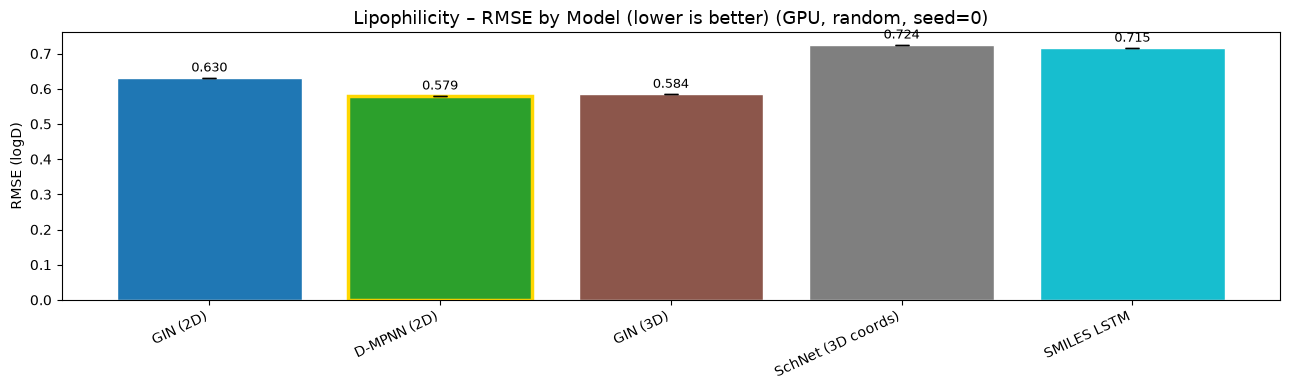

=== LIPOPHILICITY Results (5/12 models) ===
                               RMSE              MAE               R2
Model                                                                
GIN (2D)            0.6305 ± 0.0000  0.4717 ± 0.0000  0.7440 ± 0.0000
D-MPNN (2D)         0.5792 ± 0.0000  0.4282 ± 0.0000  0.7840 ± 0.0000
GIN (3D)            0.5841 ± 0.0000  0.4398 ± 0.0000  0.7803 ± 0.0000
SchNet (3D coords)  0.7242 ± 0.0000  0.5511 ± 0.0000  0.6623 ± 0.0000
SMILES LSTM         0.7151 ± 0.0000  0.5317 ± 0.0000  0.6707 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/random/gpu/lipophilicity_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/random/gpu/lipophilicity_rmse_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_proje

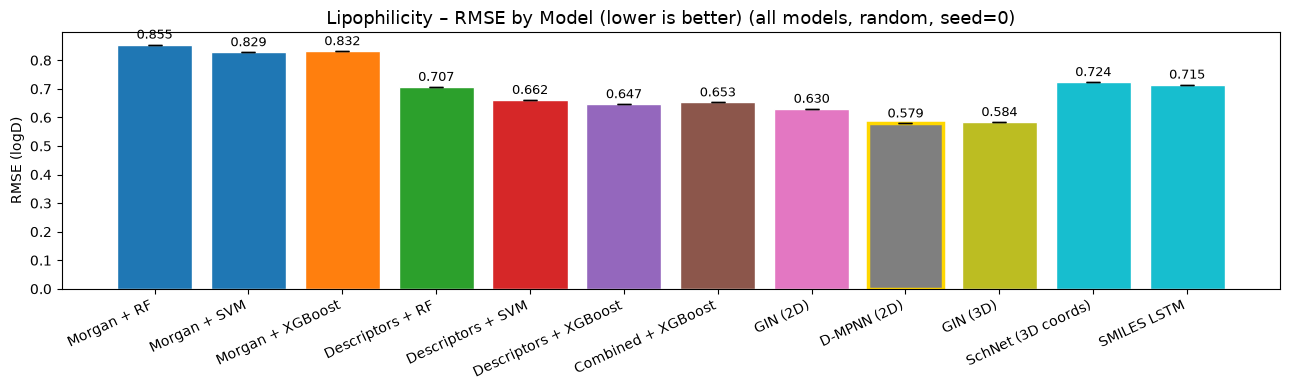

=== LIPOPHILICITY Results (12/12 models) ===
                                  RMSE              MAE               R2
Model                                                                   
Morgan + RF            0.8551 ± 0.0000  0.6373 ± 0.0000  0.5292 ± 0.0000
Morgan + SVM           0.8286 ± 0.0000  0.6177 ± 0.0000  0.5579 ± 0.0000
Morgan + XGBoost       0.8324 ± 0.0000  0.6254 ± 0.0000  0.5538 ± 0.0000
Descriptors + RF       0.7072 ± 0.0000  0.5490 ± 0.0000  0.6780 ± 0.0000
Descriptors + SVM      0.6615 ± 0.0000  0.4749 ± 0.0000  0.7182 ± 0.0000
Descriptors + XGBoost  0.6467 ± 0.0000  0.4987 ± 0.0000  0.7306 ± 0.0000
Combined + XGBoost     0.6530 ± 0.0000  0.4989 ± 0.0000  0.7254 ± 0.0000
GIN (2D)               0.6305 ± 0.0000  0.4717 ± 0.0000  0.7440 ± 0.0000
D-MPNN (2D)            0.5792 ± 0.0000  0.4282 ± 0.0000  0.7840 ± 0.0000
GIN (3D)               0.5841 ± 0.0000  0.4398 ± 0.0000  0.7803 ± 0.0000
SchNet (3D coords)     0.7242 ± 0.0000  0.5511 ± 0.0000  0.6623 ± 0.0000
SMILES

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"Lipophilicity – RMSE by Model (lower is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (logD)", minimize=True)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"Lipophilicity – RMSE by Model (lower is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (logD)", minimize=True)
else:
    print("Run CPU notebook first for combined results.")
